# USL-Suspilne Dataset Analysis

Comprehensive analysis of the dataset: duration, splits, outliers, proper nouns / surnames, and vocabulary.

**Dependencies:** numpy, matplotlib, pandas

## 1. Load Data

In [1]:
import csv
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path(".").resolve().parent.parent
ANNOTATION_PATH = ROOT / "data/usl-suspilne/annotations.csv"
POSES_DIR = ROOT / "data/usl-suspilne/poses/2d"
FEATURES_DIR = ROOT / "data/usl-suspilne/features"
FPS = 30.0

DEV_VIDEOS = {"S0o1oJ6G5qw"}
TEST_VIDEOS = {"w_LdfLKP_0o", "Nyykyn4FpNo"}


def get_split(video_id):
    if video_id in DEV_VIDEOS:
        return "dev"
    elif video_id in TEST_VIDEOS:
        return "test"
    return "train"


def normalize_text(text: str) -> str:
    tokens = text.lower().split()
    cleaned = []
    for t in tokens:
        t = re.sub(r'^[^\w]+|[^\w]+$', '', t, flags=re.UNICODE)
        if t:
            cleaned.append(t)
    return " ".join(cleaned)


# Build dataframe
rows = []
with open(ANNOTATION_PATH, newline="", encoding="utf-8") as f:
    for row in csv.DictReader(f, delimiter="|"):
        name = row["name"]
        vid = name.split("/")[0]
        clip_id = name.split("/")[1]
        text_raw = row["text"]
        text_norm = normalize_text(text_raw)
        annotator = row["annotator"]

        # Load pose to get duration
        pose_path = POSES_DIR / vid / f"{clip_id}.npy"
        if pose_path.exists():
            n_frames = np.load(pose_path).shape[0]
        else:
            n_frames = 0

        rows.append({
            "name": name,
            "video_id": vid,
            "clip_id": clip_id,
            "text_raw": text_raw,
            "text": text_norm,
            "annotator": annotator,
            "n_frames": n_frames,
            "duration_s": n_frames / FPS,
            "n_tokens": len(text_norm.split()),
            "split": get_split(vid),
        })

df = pd.DataFrame(rows)
print(f"Total clips: {len(df)}")
print(f"Total duration: {df['duration_s'].sum() / 3600:.2f} hours")
print(f"Clips with poses: {(df['n_frames'] > 0).sum()}")
df.head()

Total clips: 5116
Total duration: 7.76 hours
Clips with poses: 5113


,name,video_id,clip_id,text_raw,text,annotator,n_frames,duration_s,n_tokens,split
0,0ULOz5HM4pA/0000,0ULOz5HM4pA,0000,"18-та в Україні, ви дивитесь Суспільне новини,...",18-та в україні ви дивитесь суспільне новини м...,Volosnka,227,7.566667,23,train
1,0ULOz5HM4pA/0001,0ULOz5HM4pA,0001,Токіо надає Києву новий пакет підтримки.,токіо надає києву новий пакет підтримки,Volosnka,74,2.466667,6,train
2,0ULOz5HM4pA/0002,0ULOz5HM4pA,0002,Про таке сказав президент Володимир Зеленський...,про таке сказав президент володимир зеленський...,Volosnka,239,7.966667,18,train
3,0ULOz5HM4pA/0003,0ULOz5HM4pA,0003,"Урядовець сьогодні приїхав у Київ, і це його п...",урядовець сьогодні приїхав у київ і це його пе...,Volosnka,136,4.533333,12,train
4,0ULOz5HM4pA/0004,0ULOz5HM4pA,0004,Загалом від початку повномасштабного вторгненн...,загалом від початку повномасштабного вторгненн...,Volosnka,247,8.233333,18,train


## 2. Overview by Video & Annotator

In [2]:
# Clips per video
video_stats = df.groupby("video_id").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    split=("split", "first"),
    annotator=("annotator", "first"),
).sort_values("clips", ascending=False)

print(video_stats.to_string())
print(f"\nTotal videos: {len(video_stats)}")

             clips  duration_min  split   annotator
video_id                                           
IOflFDS2biE    507     35.662778  train   Iriha2025
d37lwXaSjs4    500     41.392222  train    Volosnka
jj5jiyl2mh0    422     37.111111  train   Iriha2025
9NMtlqDBY_s    355     27.213889  train    Volosnka
VVjY5HVY0jg    350     26.878889  train    Volosnka
4FUDnWC9UJA    315     25.777222  train    Volosnka
yPYU48eSeBg    293     27.601111  train  LS04071977
6O0ZiSgKJNc    245     22.202778  train    Volosnka
0ULOz5HM4pA    228     29.917222  train    Volosnka
Nyykyn4FpNo    225     19.981667   test   Iriha2025
g5Az2FHUQBU    185     14.992222  train    Volosnka
eYEK-n2alOA    183     16.093333  train    Volosnka
cNT6ajjEwVU    169     22.240556  train   Iriha2025
KUDt_SKkPUE    146     16.453889  train   Iriha2025
uGMgleLkjho    145     12.998333  train   Iriha2025
Q3yRVXmZdGQ    139     10.987222  train   Iriha2025
A2hCZVvtUSE    123     15.565556  train   Iriha2025
S0o1oJ6G5qw 

In [3]:
# Clips per annotator
ann_stats = df.groupby("annotator").agg(
    clips=("name", "count"),
    duration_min=("duration_s", lambda x: x.sum() / 60),
    videos=("video_id", "nunique"),
)
print(ann_stats)

            clips  duration_min  videos
annotator                              
Iriha2025    2164    204.617778      12
LS04071977    293     27.601111       1
Volosnka     2659    233.633333      11


## 3. Split Analysis

In [4]:
split_stats = df.groupby("split").agg(
    clips=("name", "count"),
    hours=("duration_s", lambda x: x.sum() / 3600),
    videos=("video_id", "nunique"),
    avg_tokens=("n_tokens", "mean"),
    avg_duration=("duration_s", "mean"),
).reindex(["train", "dev", "test"])

split_stats["clip_%"] = split_stats["clips"] / split_stats["clips"].sum() * 100
split_stats["hour_%"] = split_stats["hours"] / split_stats["hours"].sum() * 100

print(split_stats.round(2).to_string())

       clips  hours  videos  avg_tokens  avg_duration  clip_%  hour_%
split                                                                
train   4705   7.15      21       11.63          5.47   91.97   92.04
dev      115   0.15       1       10.17          4.71    2.25    1.94
test     296   0.47       2       11.89          5.69    5.79    6.02


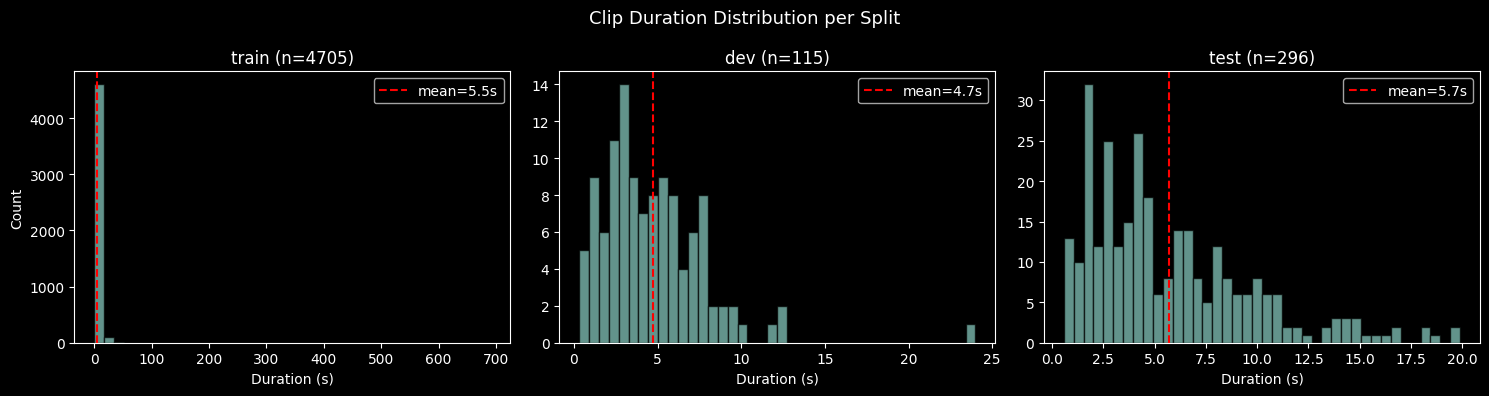

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "dev", "test"]):
    subset = df[df["split"] == split]
    ax.hist(subset["duration_s"], bins=40, edgecolor="black", alpha=0.7)
    ax.axvline(subset["duration_s"].mean(), color="red", linestyle="--",
               label=f"mean={subset['duration_s'].mean():.1f}s")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Duration (s)")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Clip Duration Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

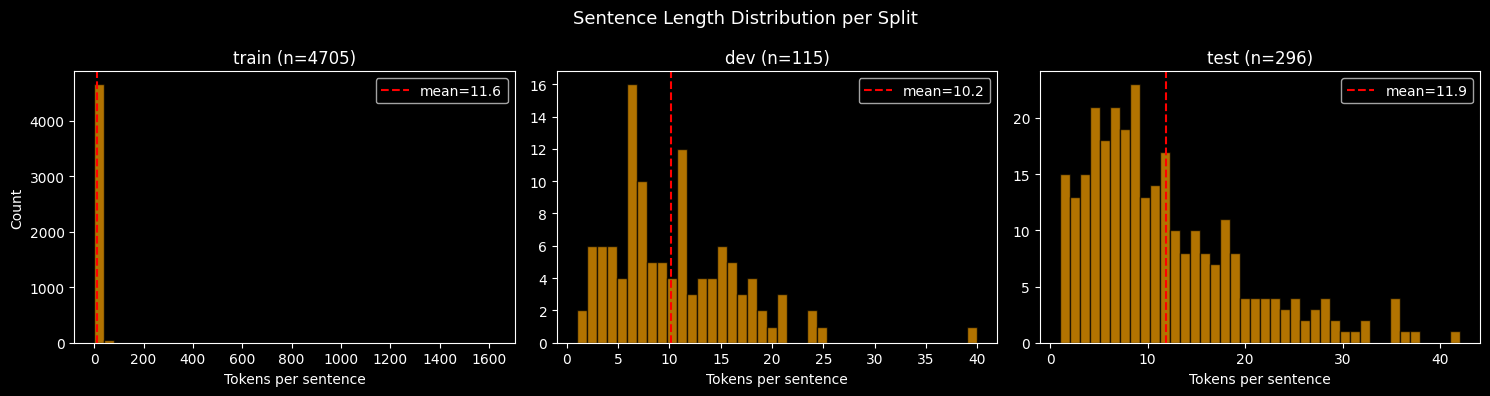

In [6]:
# Token-length distribution per split
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, split in zip(axes, ["train", "dev", "test"]):
    subset = df[df["split"] == split]
    ax.hist(subset["n_tokens"], bins=40, edgecolor="black", alpha=0.7, color="orange")
    ax.axvline(subset["n_tokens"].mean(), color="red", linestyle="--",
               label=f"mean={subset['n_tokens'].mean():.1f}")
    ax.set_title(f"{split} (n={len(subset)})")
    ax.set_xlabel("Tokens per sentence")
    ax.legend()

axes[0].set_ylabel("Count")
plt.suptitle("Sentence Length Distribution per Split", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Outlier Detection

We look for clips that may hurt training quality:
- **Very short** (<1s) — not enough motion signal
- **Very long** (>30s) — likely segmentation errors
- **Missing poses** — no pose file extracted
- **Single-token** — filler words like "так", "дякую"
- **Token-rate outliers** — text/duration mismatch (bad alignment)

In [7]:
df["tokens_per_sec"] = df["n_tokens"] / df["duration_s"].replace(0, np.nan)

# Outlier flags
df["flag_short"] = df["duration_s"] < 1.0
df["flag_long"] = df["duration_s"] > 30.0
df["flag_no_pose"] = df["n_frames"] == 0
df["flag_single_tok"] = df["n_tokens"] <= 1
df["flag_high_rate"] = df["tokens_per_sec"] > df["tokens_per_sec"].quantile(0.99)
df["flag_low_rate"] = df["tokens_per_sec"] < df["tokens_per_sec"].quantile(0.01)
df["flag_any"] = df[["flag_short", "flag_long", "flag_no_pose", "flag_single_tok", "flag_high_rate", "flag_low_rate"]].any(axis=1)

outlier_summary = pd.DataFrame({
    "Category": ["< 1s duration", "> 30s duration", "Missing poses", "Single token (0-1)",
                  "Top 1% token rate", "Bottom 1% token rate", "Any flag"],
    "Count": [df["flag_short"].sum(), df["flag_long"].sum(), df["flag_no_pose"].sum(),
              df["flag_single_tok"].sum(), df["flag_high_rate"].sum(), df["flag_low_rate"].sum(),
              df["flag_any"].sum()],
})
outlier_summary["% of dataset"] = (outlier_summary["Count"] / len(df) * 100).round(1)
outlier_summary

,Category,Count,% of dataset
0,< 1s duration,188,3.7
1,> 30s duration,12,0.2
2,Missing poses,3,0.1
3,Single token (0-1),101,2.0
4,Top 1% token rate,51,1.0
5,Bottom 1% token rate,52,1.0
6,Any flag,314,6.1


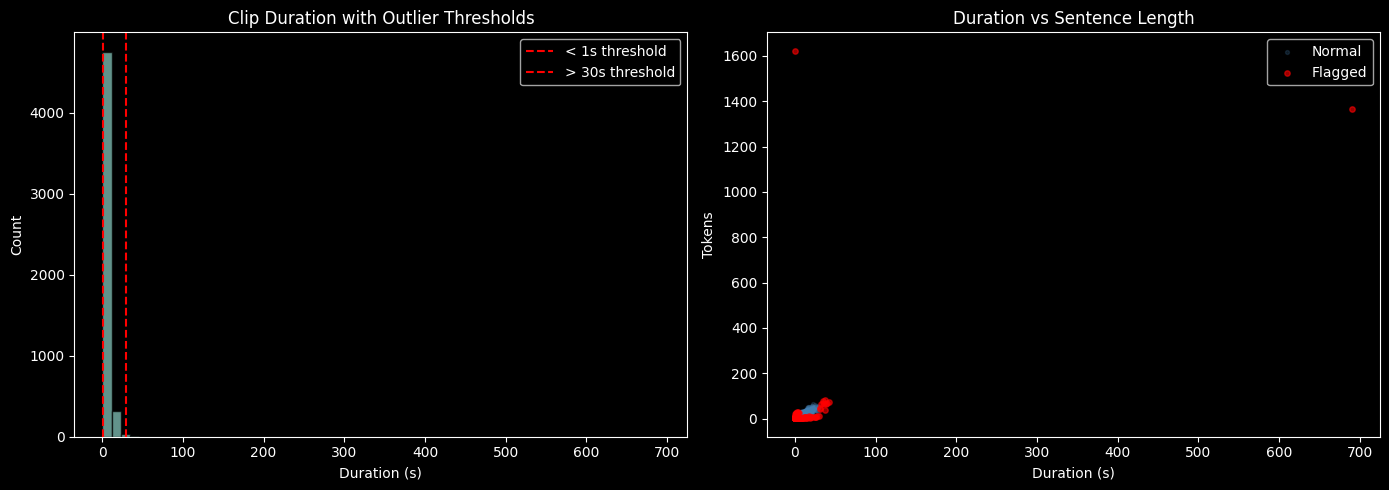

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration histogram with outlier thresholds
ax = axes[0]
ax.hist(df["duration_s"], bins=60, edgecolor="black", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", linewidth=1.5, label="< 1s threshold")
ax.axvline(30.0, color="red", linestyle="--", linewidth=1.5, label="> 30s threshold")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Count")
ax.set_title("Clip Duration with Outlier Thresholds")
ax.legend()

# Duration vs token count scatter
ax = axes[1]
normal = df[~df["flag_any"]]
flagged = df[df["flag_any"]]
ax.scatter(normal["duration_s"], normal["n_tokens"], alpha=0.2, s=8, color="steelblue", label="Normal")
ax.scatter(flagged["duration_s"], flagged["n_tokens"], alpha=0.6, s=15, color="red", label="Flagged")
ax.set_xlabel("Duration (s)")
ax.set_ylabel("Tokens")
ax.set_title("Duration vs Sentence Length")
ax.legend()

plt.tight_layout()
plt.show()

### 4a. Very short clips (< 1s)

In [9]:
short = df[df["flag_short"]].sort_values("duration_s")
print(f"{len(short)} clips under 1 second")
short[["name", "split", "duration_s", "n_tokens", "text"]].head(15)

188 clips under 1 second


,name,split,duration_s,n_tokens,text
3196,cNT6ajjEwVU/0048,train,0.000000,9,гарріс продовжувати намагатися продовжувати по...
2793,SG9xYYOLBNI/0033,train,0.000000,21,тому яким чином переформатують оці кафедральні...
2797,SG9xYYOLBNI/0037,train,0.000000,1623,розуміння що робити як робити ми більше ніколи...
2696,S0o1oJ6G5qw/0051,dev,0.300000,2,доброго дня
225,0ULOz5HM4pA/0232,train,0.333333,1,дякую
1217,9NMtlqDBY_s/0236,train,0.366667,1,обліт
4544,jj5jiyl2mh0/0359,train,0.366667,1,ось
4568,jj5jiyl2mh0/0383,train,0.366667,2,мета першочергова
3709,d37lwXaSjs4/0392,train,0.366667,3,і за що
984,9NMtlqDBY_s/0003,train,0.400000,1,вітаю


### 4b. Very long clips (> 30s)

In [10]:
long = df[df["flag_long"]].sort_values("duration_s", ascending=False)
print(f"{len(long)} clips over 30 seconds")
long[["name", "split", "duration_s", "n_tokens", "text"]]

12 clips over 30 seconds


,name,split,duration_s,n_tokens,text
218,0ULOz5HM4pA/0225,train,690.833333,1366,житло сьогодні в україні цього законодавства н...
3184,cNT6ajjEwVU/0036,train,41.966667,72,ви знаєте 22-й рік багато особливо в 23-му і в...
5084,yPYU48eSeBg/0262,train,39.633333,68,так на жаль ми бачимо зміну в риториці америка...
2132,KUDt_SKkPUE/0112,train,38.366667,64,от звісно якщо до нашої роботи власне буде пов...
4479,jj5jiyl2mh0/0294,train,38.000000,36,не евакуювалися з міста ситуація в місті вкрай...
1383,A2hCZVvtUSE/0047,train,37.366667,82,зараз буде дуже суб'єктивна моя оцінка не треб...
3754,d37lwXaSjs4/0438,train,36.300000,64,якраз щодо розпорошеної генерації яка була зір...
1386,A2hCZVvtUSE/0050,train,34.366667,77,так він чудово мабуть розуміє що це насправді ...
4975,yPYU48eSeBg/0153,train,34.300000,67,скажуть також артисти що для них важливо відро...
303,2Nnz697BVTw/0075,train,32.233333,66,і ось цим ми зараз теж займаємось я нещодавно ...


### 4c. Missing poses & single-token clips

In [11]:
missing = df[df["flag_no_pose"]]
print(f"Missing poses: {len(missing)}")
if len(missing) > 0:
    display(missing[["name", "split", "n_tokens", "text"]])

print(f"\nSingle-token clips: {df['flag_single_tok'].sum()}")
single = df[df["flag_single_tok"]]
# Show most common filler words
single_words = Counter(single["text"])
print("\nMost common single-token texts:")
for word, count in single_words.most_common(15):
    print(f"  {word:<20} {count:>3}x")

Missing poses: 3


,name,split,n_tokens,text
2793,SG9xYYOLBNI/0033,train,21,тому яким чином переформатують оці кафедральні...
2797,SG9xYYOLBNI/0037,train,1623,розуміння що робити як робити ми більше ніколи...
3196,cNT6ajjEwVU/0048,train,9,гарріс продовжувати намагатися продовжувати по...



Single-token clips: 101

Most common single-token texts:
  так                   13x
  дякую                  9x
  зрозуміло              9x
  вітаю                  6x
  вітаємо                3x
  послухаймо             3x
  угу                    3x
  дякуємо                3x
  послухаємо             2x
  дивіться               2x
  ділиться               2x
  чому                   2x
  ну                     1x
  дава                   1x
  україна                1x


### 4d. Token-rate outliers (text ↔ duration mismatch)

In [12]:
print("Token rate (tokens/sec) percentiles:")
print(df["tokens_per_sec"].describe().round(2).to_string())

print(f"\n--- Top 1% rate (>{df['tokens_per_sec'].quantile(0.99):.1f} tok/s) — text too long for clip duration ---")
high = df[df["flag_high_rate"]].sort_values("tokens_per_sec", ascending=False)
display(high[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text"]].head(10))

print(f"\n--- Bottom 1% rate (<{df['tokens_per_sec'].quantile(0.01):.1f} tok/s) — clip too long for text ---")
low = df[df["flag_low_rate"]].sort_values("tokens_per_sec")
display(low[["name", "split", "duration_s", "n_tokens", "tokens_per_sec", "text"]].head(10))

Token rate (tokens/sec) percentiles:
count    5113.00
mean        2.26
std         0.96
min         0.16
25%         1.78
50%         2.15
75%         2.56
max        16.00

--- Top 1% rate (>5.3 tok/s) — text too long for clip duration ---


,name,split,duration_s,n_tokens,tokens_per_sec,text
2869,VVjY5HVY0jg/0071,train,0.500000,8,16.000000,тож удімка повертайся обов'язково з перемогою ...
2913,VVjY5HVY0jg/0115,train,0.966667,15,15.517241,мій син михайло був у складі полку азов і в 22...
2979,VVjY5HVY0jg/0181,train,1.966667,26,13.220339,я розумію що цивільних міняють не так часто що...
1905,IOflFDS2biE/0446,train,1.000000,13,13.000000,вітаємо що він потім відуть подолу і вийде на ...
2997,VVjY5HVY0jg/0199,train,2.000000,26,13.000000,11 січня київський міський голова віталій клич...
2830,VVjY5HVY0jg/0032,train,0.800000,10,12.500000,де саме оголосили небезпеку ви зараз можете по...
3010,VVjY5HVY0jg/0212,train,1.000000,12,12.000000,там будівля чи капітальні ремонти розбудова ад...
3398,d37lwXaSjs4/0081,train,0.433333,5,11.538462,каже що вона не виглядає
2974,VVjY5HVY0jg/0176,train,2.966667,31,10.449438,я дуже сподіваюся що вона не буде нічого таког...
2941,VVjY5HVY0jg/0143,train,0.966667,10,10.344828,донька пані оксани марія згадує як дізналася п...



--- Bottom 1% rate (<0.6 tok/s) — clip too long for text ---


,name,split,duration_s,n_tokens,tokens_per_sec,text
3140,VVjY5HVY0jg/0342,train,18.533333,3,0.161871,захід був благодійним
3023,VVjY5HVY0jg/0225,train,6.000000,1,0.166667,ні
2872,VVjY5HVY0jg/0074,train,10.700000,2,0.186916,поступила пропозиція
3024,VVjY5HVY0jg/0226,train,14.000000,3,0.214286,на житловій забудові
3066,VVjY5HVY0jg/0268,train,4.266667,1,0.234375,чекатіна
3134,VVjY5HVY0jg/0336,train,25.233333,6,0.237781,кубок здобула команда покрова-2 зі львова
710,6O0ZiSgKJNc/0090,train,3.933333,1,0.254237,аналітика
722,6O0ZiSgKJNc/0102,train,15.466667,4,0.258621,суспільне новини о 19-тій
3501,d37lwXaSjs4/0184,train,24.500000,7,0.285714,ефір на суспільному продовжує команда суспільн...
3012,VVjY5HVY0jg/0214,train,7.000000,2,0.285714,декілька інвесторів


### 4e. Impact of removing flagged clips

In [13]:
clean = df[~df["flag_any"]]
print(f"Before filtering: {len(df):>5} clips, {df['duration_s'].sum()/3600:.2f}h")
print(f"After filtering:  {len(clean):>5} clips, {clean['duration_s'].sum()/3600:.2f}h")
print(f"Removed:          {len(df)-len(clean):>5} clips, {(df['duration_s'].sum()-clean['duration_s'].sum())/3600:.2f}h")
print()

for split in ["train", "dev", "test"]:
    before = df[df["split"] == split]
    after = clean[clean["split"] == split]
    print(f"  {split}: {len(before)} → {len(after)} clips "
          f"({before['duration_s'].sum()/3600:.2f}h → {after['duration_s'].sum()/3600:.2f}h)")

Before filtering:  5116 clips, 7.76h
After filtering:   4802 clips, 7.26h
Removed:            314 clips, 0.51h

  train: 4705 → 4412 clips (7.15h → 6.65h)
  dev: 115 → 107 clips (0.15h → 0.15h)
  test: 296 → 283 clips (0.47h → 0.46h)


## 5. Proper Nouns & Surnames

In [14]:
# Detect proper nouns via capitalization in the RAW text.
# Ukrainian proper nouns are capitalized; we skip sentence-initial words.

def extract_proper_nouns(text_raw: str) -> list[str]:
    """Return likely proper nouns (capitalized non-initial words)."""
    tokens = text_raw.split()
    proper = []
    for i, tok in enumerate(tokens):
        # Strip punctuation for check
        clean = re.sub(r'^[^\w]+|[^\w]+$', '', tok, flags=re.UNICODE)
        if not clean:
            continue
        # Skip first word (sentence-initial capitalization)
        if i == 0:
            continue
        # Skip all-caps (abbreviations like ЗСУ, НАТО)
        if clean == clean.upper() and len(clean) > 1:
            continue
        # Capitalized = proper noun candidate
        if clean[0].isupper():
            proper.append(clean.lower())
    return proper


# Extract per clip
df["proper_nouns"] = df["text_raw"].apply(extract_proper_nouns)
df["n_proper"] = df["proper_nouns"].apply(len)

all_proper = [w for words in df["proper_nouns"] for w in words]
proper_counter = Counter(all_proper)

print(f"Total proper noun tokens: {len(all_proper)}")
print(f"Unique proper nouns: {len(proper_counter)}")
print(f"Clips containing proper nouns: {(df['n_proper'] > 0).sum()} / {len(df)} ({(df['n_proper'] > 0).mean()*100:.1f}%)")
print(f"\nMost common proper nouns:")
for word, count in proper_counter.most_common(30):
    print(f"  {word:<25} {count:>4}")

Total proper noun tokens: 3993
Unique proper nouns: 1358
Clips containing proper nouns: 1954 / 5116 (38.2%)

Most common proper nouns:
  україни                    181
  україні                     92
  трамп                       67
  україна                     59
  трампа                      53
  сполучених                  52
  росії                       37
  америки                     37
  штатів                      33
  штатах                      31
  суспільному                 28
  суспільне                   26
  кореї                       26
  києва                       26
  україну                     25
  дональд                     25
  володимир                   24
  гарріс                      24
  зеленський                  22
  дональда                    20
  києві                       19
  тетяна                      18
  ради                        18
  зеленського                 18
  суспільного                 17
  ігор                        16
  криму

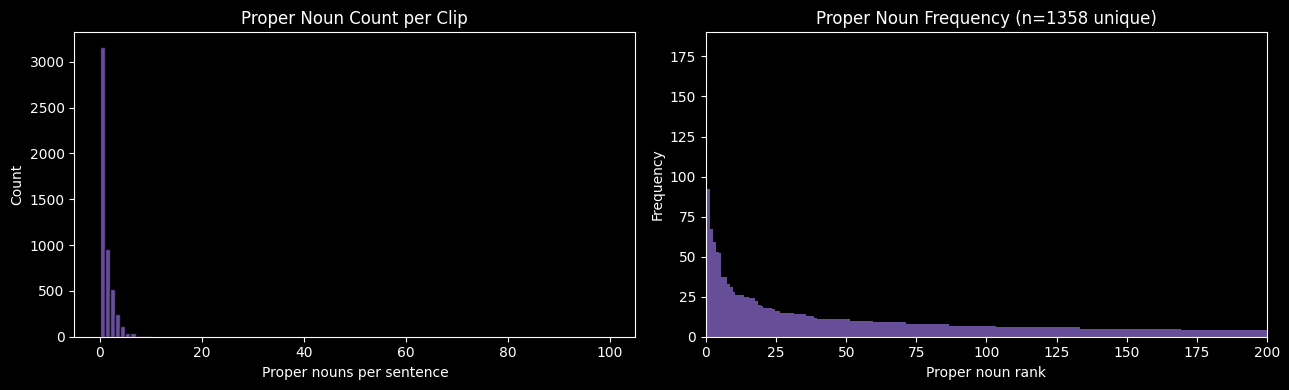

Proper nouns appearing only once: 761 / 1358 (56.0%)


In [15]:
# Proper noun frequency distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# How many proper nouns per sentence
ax1.hist(df["n_proper"], bins=range(0, df["n_proper"].max() + 2),
         edgecolor="black", alpha=0.7, color="mediumpurple")
ax1.set_xlabel("Proper nouns per sentence")
ax1.set_ylabel("Count")
ax1.set_title("Proper Noun Count per Clip")

# Frequency of individual proper nouns
pn_freqs = sorted(proper_counter.values(), reverse=True)
ax2.bar(range(len(pn_freqs)), pn_freqs, width=1.0, color="mediumpurple", alpha=0.7)
ax2.set_xlabel("Proper noun rank")
ax2.set_ylabel("Frequency")
ax2.set_title(f"Proper Noun Frequency (n={len(proper_counter)} unique)")
ax2.set_xlim(0, min(200, len(pn_freqs)))

plt.tight_layout()
plt.show()

# Hapax proper nouns
pn_hapax = sum(1 for c in proper_counter.values() if c == 1)
print(f"Proper nouns appearing only once: {pn_hapax} / {len(proper_counter)} ({pn_hapax/len(proper_counter)*100:.1f}%)")

In [16]:
# Vocabulary and OOV with vs without proper nouns
proper_set = set(proper_counter.keys())

for label, filter_proper in [("All tokens", False), ("Without proper nouns", True)]:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    split_tokens = {}
    for split in ["train", "dev", "test"]:
        subset = df[df["split"] == split]
        tokens = []
        for text in subset["text"]:
            toks = text.split()
            if filter_proper:
                toks = [t for t in toks if t not in proper_set]
            tokens.extend(toks)
        split_tokens[split] = tokens

    train_vocab = set(split_tokens["train"])
    print(f"\n{'Split':<8} {'Tokens':>8} {'Types':>7}")
    print("-" * 28)
    for s in ["train", "dev", "test"]:
        types = len(set(split_tokens[s]))
        print(f"{s:<8} {len(split_tokens[s]):>8} {types:>7}")

    print(f"\n{'Split':<8} {'OOV tokens':>11} {'OOV %':>7} {'OOV types':>10} {'OOV type %':>11}")
    print("-" * 52)
    for s in ["dev", "test"]:
        tokens = split_tokens[s]
        types = set(tokens)
        oov_tokens = [t for t in tokens if t not in train_vocab]
        oov_types = types - train_vocab
        print(f"{s:<8} {len(oov_tokens):>11} {len(oov_tokens)/max(len(tokens),1)*100:>6.1f}% "
              f"{len(oov_types):>10} {len(oov_types)/max(len(types),1)*100:>10.1f}%")


  All tokens

Split      Tokens   Types
----------------------------
train       54740   12044
dev          1170     669
test         3519    1583

Split     OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------
dev              153   13.1%        138       20.6%
test             598   17.0%        500       31.6%

  Without proper nouns

Split      Tokens   Types
----------------------------
train       44194   10748
dev           893     577
test         2844    1414

Split     OOV tokens   OOV %  OOV types  OOV type %
----------------------------------------------------
dev              138   15.5%        124       21.5%
test             524   18.4%        452       32.0%


In [17]:
# What fraction of OOV tokens ARE proper nouns?
train_tokens_all = [t for text in df[df["split"]=="train"]["text"] for t in text.split()]
train_vocab_all = set(train_tokens_all)

for s in ["dev", "test"]:
    tokens = [t for text in df[df["split"]==s]["text"] for t in text.split()]
    oov = [t for t in tokens if t not in train_vocab_all]
    oov_proper = [t for t in oov if t in proper_set]
    oov_other = [t for t in oov if t not in proper_set]
    print(f"{s}: {len(oov)} OOV tokens — {len(oov_proper)} proper nouns ({len(oov_proper)/max(len(oov),1)*100:.1f}%), "
          f"{len(oov_other)} other ({len(oov_other)/max(len(oov),1)*100:.1f}%)")

dev: 153 OOV tokens — 15 proper nouns (9.8%), 138 other (90.2%)
test: 598 OOV tokens — 74 proper nouns (12.4%), 524 other (87.6%)


## 6. Updated Vocabulary Stats

In [18]:
train_counter = Counter(train_tokens_all)
vocab_size = len(train_counter)
total_tokens = sum(train_counter.values())

print(f"Train vocabulary: {vocab_size} types, {total_tokens} tokens")
print()

# Frequency buckets
freq_buckets = {"1": 0, "2": 0, "3-5": 0, "6-10": 0, "11-50": 0, "51+": 0}
for word, count in train_counter.items():
    if count == 1:
        freq_buckets["1"] += 1
    elif count == 2:
        freq_buckets["2"] += 1
    elif count <= 5:
        freq_buckets["3-5"] += 1
    elif count <= 10:
        freq_buckets["6-10"] += 1
    elif count <= 50:
        freq_buckets["11-50"] += 1
    else:
        freq_buckets["51+"] += 1

print(f"{'Frequency':<12} {'Types':>7} {'% of vocab':>10}")
print("-" * 32)
for bucket, count in freq_buckets.items():
    print(f"{bucket:<12} {count:>7} {count / vocab_size * 100:>9.1f}%")

hapax = freq_buckets["1"]
print(f"\nHapax legomena: {hapax} / {vocab_size} = {hapax / vocab_size * 100:.1f}% of vocabulary")

Train vocabulary: 12044 types, 54740 tokens

Frequency      Types % of vocab
--------------------------------
1               6420      53.3%
2               2274      18.9%
3-5             1865      15.5%
6-10             815       6.8%
11-50            559       4.6%
51+              111       0.9%

Hapax legomena: 6420 / 12044 = 53.3% of vocabulary


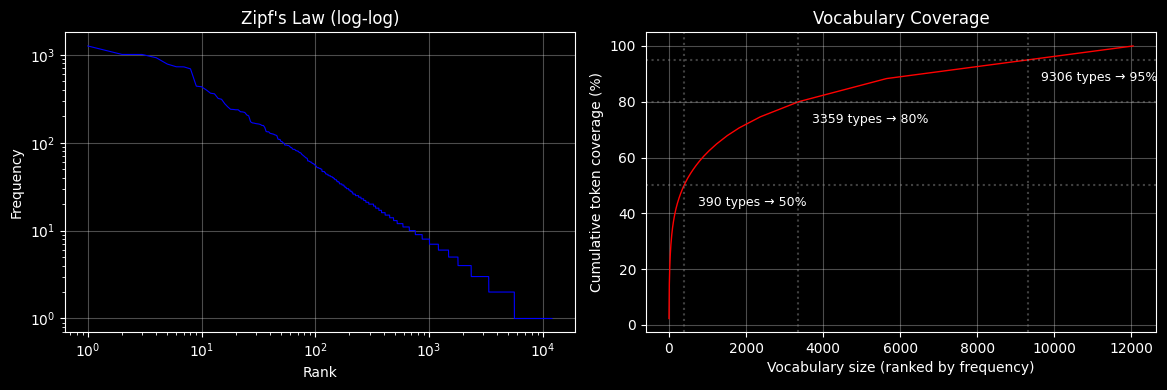

In [19]:
# Zipf's law + cumulative coverage
sorted_counts = sorted(train_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_counts) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ranks, sorted_counts, "b-", linewidth=0.8)
ax1.set_xlabel("Rank")
ax1.set_ylabel("Frequency")
ax1.set_title("Zipf's Law (log-log)")
ax1.grid(True, alpha=0.3)

cumsum = np.cumsum(sorted_counts) / sum(sorted_counts) * 100
ax2.plot(ranks, cumsum, "r-", linewidth=1)
for pct in [50, 80, 95]:
    idx = np.searchsorted(cumsum, pct)
    ax2.axhline(pct, color="gray", linestyle=":", alpha=0.5)
    ax2.axvline(idx, color="gray", linestyle=":", alpha=0.5)
    ax2.annotate(f"{idx} types → {pct}%", (idx, pct),
                 textcoords="offset points", xytext=(10, -15), fontsize=9)
ax2.set_xlabel("Vocabulary size (ranked by frequency)")
ax2.set_ylabel("Cumulative token coverage (%)")
ax2.set_title("Vocabulary Coverage")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Summary & Recommendations

In [20]:
print("=" * 60)
print("  SUMMARY")
print("=" * 60)
print(f"\nDataset: {len(df)} clips, {df['duration_s'].sum()/3600:.2f} hours")
print(f"Videos: {df['video_id'].nunique()}")
print(f"Annotators: {df['annotator'].nunique()}")
print()

for split in ["train", "dev", "test"]:
    s = df[df["split"] == split]
    print(f"{split:>5}: {len(s):>5} clips, {s['duration_s'].sum()/3600:.2f}h, "
          f"{s['video_id'].nunique()} videos, avg {s['duration_s'].mean():.1f}s/clip")

print(f"\n--- Potential issues ---")
print(f"Clips <1s: {len(df[df['duration_s'] < 1.0])}")
print(f"Clips >30s: {len(df[df['duration_s'] > 30.0])}")
print(f"Missing poses: {len(df[df['n_frames'] == 0])}")
print(f"Single-token clips: {len(df[df['n_tokens'] <= 1])}")
print(f"\n--- Proper nouns ---")
print(f"Unique proper nouns: {len(proper_counter)}")
print(f"Clips with proper nouns: {(df['n_proper'] > 0).sum()} ({(df['n_proper'] > 0).mean()*100:.1f}%)")
print(f"Proper noun hapax: {pn_hapax} / {len(proper_counter)} ({pn_hapax/len(proper_counter)*100:.1f}%)")

  SUMMARY

Dataset: 5116 clips, 7.76 hours
Videos: 24
Annotators: 3

train:  4705 clips, 7.15h, 21 videos, avg 5.5s/clip
  dev:   115 clips, 0.15h, 1 videos, avg 4.7s/clip
 test:   296 clips, 0.47h, 2 videos, avg 5.7s/clip

--- Potential issues ---
Clips <1s: 188
Clips >30s: 12
Missing poses: 3
Single-token clips: 101

--- Proper nouns ---
Unique proper nouns: 1358
Clips with proper nouns: 1954 (38.2%)
Proper noun hapax: 761 / 1358 (56.0%)
